In [309]:
import os
import math
import json
import warnings
import itertools
from datetime import datetime
from typing import List, Tuple

warnings.filterwarnings("ignore")

In [310]:
os.environ.setdefault("FINTORCH_BASE_TIME_FRAME", "60")

'60'

In [311]:
import numpy as np 
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from fintorch.enum import TimeFrame
from fintorch.exchange import ONLINE_EXCHANGE
from fintorch.utils.preprocess import remove_price_dependency
from fintorch.utils.args import DefaultArgumentParser
from fintorch.utils.plot import draw_candlestick_plot, draw_labels, draw_predictions

In [312]:
string_args = [
    "--start-date", "2024-01-01",
    "--stop-date", "2024-06-01",
    "--time-frame", "60",
    "--symbol", "BTC-USDT"
]

args = DefaultArgumentParser.parse(args=string_args)

In [325]:
sdf = ONLINE_EXCHANGE.future.data.update_candles_dataframe(symbol=args.symbol, time_frame=args.time_frame)
sdf = ONLINE_EXCHANGE.future.data.get_candles_dataframe(symbol=args.symbol, time_frame=args.time_frame).copy()

sdf

,open,high,low,close,volume,trade
timestamp,,,,,,
1705395660,43032.7,43040.0,42985.6,43003.7,201.772,3323
1705395720,43004.5,43016.0,42960.0,42967.3,534.556,4093
1705395780,42967.3,42976.5,42954.2,42957.8,117.148,1847
1705395840,42957.9,42965.7,42928.9,42942.2,245.105,3502
1705395900,42942.3,42953.0,42919.0,42942.6,134.988,1928
...,...,...,...,...,...,...
1712271780,68010.9,68043.9,68006.0,68043.8,84.962,1555
1712271840,68043.9,68104.0,68043.8,68047.9,251.531,2725
1712271900,68020.4,68078.2,68020.4,68020.9,103.463,1610


In [719]:
def process_df(df: pd.DataFrame, lookahead: int) -> pd.DataFrame:
    df["cmax"] = df.close.rolling(window=lookahead * 2, center=True).max()
    df["cmin"] = df.close.rolling(window=lookahead * 2, center=True).min()
    df["isfh"] = df.close == df.cmax
    df["isfl"] = df.close == df.cmin
    df["isf"] = df.isfh | df.isfl
    
    df["fmax"] = df.close.rolling(window=lookahead).max().shift(-lookahead)
    df["fmin"] = df.close.rolling(window=lookahead).min().shift(-lookahead)
    df["upside"] = np.abs(df.fmax - df.close)
    df["downside"] = np.abs(df.fmin - df.close)
    df["long"] = df.upside - df.downside
    df["short"] = df.downside - df.upside
    df = df.dropna()

    return df
    
def find_trend_line(df: pd.DataFrame, lookahead: int) -> Tuple[float, float]:
    def fun(x: List, df: pd.DataFrame):
        slope, intercept = x

        df = df.copy()
        df["line"] = df.index * slope + intercept
        df["distance"] = np.abs(df.close - df.line)
        df["touch"] = (df.distance < 0.1)
        
        mean_distance = df.distance[df.isfl].mean()
        mean_profit = df.short[df.touch].mean() or 0
        objective = mean_profit - mean_distance

        # print(x)
        # print(df.line)
        # print(mean_distance)
        # print(mean_profit)
        # print(objective)
        # print()
        
        return -objective

    
    df = process_df(df=df.copy(), lookahead=lookahead)

    args=(df)
    x0 = [0, 0]
    bounds = [(-1, 1), (-1, 1)]
    result = minimize(fun=fun, x0=x0, args=args, method='SLSQP', bounds=bounds)
    slope, intercept = result.x

    return slope, intercept, df

-0.0042780583333333335
-0.004278589808082581
-0.004278073234494527
nan
nan
nan
-0.03268005833333334
-0.006344358269471565
-0.0017787005876708712
-0.0017785962795425143
-0.0017787055547246024
-0.3819508458822385
-0.09586874549631962
-0.024143807304494936
-0.006468898272806865
-0.002194893232736545
-0.0019379779091953312
-0.0018349174221007902
-0.0017936007546313724
-0.0017771027885337025
-0.0017706898276596999
-0.0017704762443492548
-0.0017706848606059687
-0.001305289665059295
-0.00130507608174885
-0.0013052846980055638
-0.006417387729607817
-0.0018754724756089708
-0.0012343896272259598
-0.0012341760439155147
-0.0012343846601722286
-0.028153336084252103
-0.005257539845765964
-0.001814759643007535
-0.0012972893207822355
-0.0012259874222215646
-0.0012257738389111195
-0.0012259824551678334
-0.13367215297014487
-0.02178130434487922
-0.004310782157169724
-0.001686458483675489
-0.0012912213418592813
-0.0012314233337556684
-0.0012247976111476701
-0.001224584027837225
-0.001224792644093939
-0.6

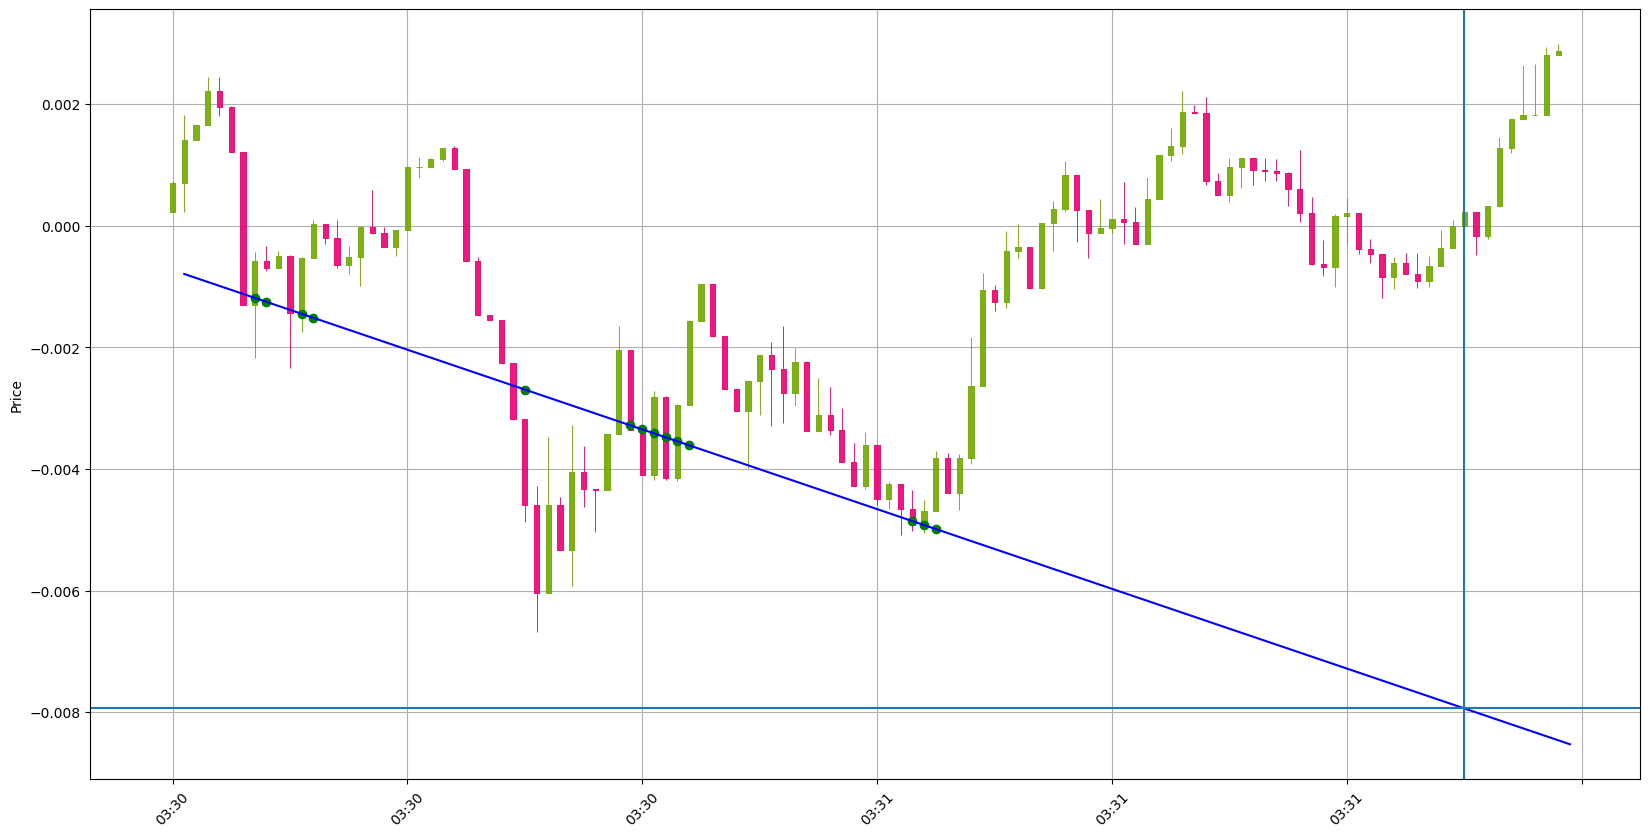

In [732]:
LENGTH = 120
TEST_INDEX = LENGTH - 20


pdf = sdf[-LENGTH:]
pdf = remove_price_dependency(df=pdf)
pdf = pdf.reset_index(drop=True)
pdf = np.round(pdf, 6)
pdf = pdf.dropna()


fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 10))
draw_candlestick_plot(ax=ax, df=pdf)
ax.grid()

slope, intercept, _ = find_trend_line(df=pdf[:TEST_INDEX], lookahead=10)
pdf["line"] = pdf.index * slope + intercept
pdf["buy"] = (pdf.low < pdf.line) & (pdf.line < pdf.high)

ax.plot(pdf.line[pdf.buy], "go")
ax.plot(pdf.line, "b")

TEST_INDEX = LENGTH - 10
order_price = TEST_INDEX * slope + intercept
ax.axvline(TEST_INDEX)
ax.axhline(order_price)

In [733]:
df = sdf.copy()[-1440 * 5:]
df.insert(0, "datetime", [datetime.fromtimestamp(ts) for ts in df.index])
df["roc"] = df.close / df.open - 1
df["aroc"] = np.abs(df.roc).rolling(window=10).mean()
df = df.reset_index(drop=True)
df = df.dropna()

df

,datetime,open,high,low,close,volume,trade,roc,aroc
9,2024-03-31 02:47:00,69767.6,69785.7,69762.0,69762.0,33.444,727,-0.000080,0.000188
10,2024-03-31 02:48:00,69762.0,69770.7,69760.0,69768.7,12.086,471,0.000096,0.000175
11,2024-03-31 02:49:00,69768.7,69776.6,69748.1,69748.1,49.386,775,-0.000295,0.000186
12,2024-03-31 02:50:00,69748.0,69748.1,69717.1,69719.9,51.215,964,-0.000403,0.000205
13,2024-03-31 02:51:00,69719.9,69736.3,69667.0,69679.1,573.819,2629,-0.000585,0.000232
...,...,...,...,...,...,...,...,...,...
7195,2024-04-05 02:33:00,68010.9,68043.9,68006.0,68043.8,84.962,1555,0.000484,0.000376
7196,2024-04-05 02:34:00,68043.9,68104.0,68043.8,68047.9,251.531,2725,0.000059,0.000364
7197,2024-04-05 02:35:00,68020.4,68078.2,68020.4,68020.9,103.463,1610,0.000007,0.000353
7198,2024-04-05 02:36:00,68020.9,68097.2,68020.4,68087.7,154.943,2007,0.000982,0.000426


In [730]:
DEBUG = False
LOOKBACK = 120
TPM = 30
SLM = 10
VAR = 0.1

bars_list = []
profits_list = []
leverages_list = []

line_index = None
order_index, order_price = None, None
entry_index, entry_price = None, None
for index in tqdm(range(LOOKBACK, len(df))):
    if DEBUG:
        o = df.open.iloc[index]
        h = df.high.iloc[index]
        l = df.low.iloc[index]
        c = df.close.iloc[index]
        print("{} {} {} {} {}".format(df.datetime.iloc[index], o, h, l, c))
        
    if entry_index is None:
        if line_index is None or 60 < index - line_index:
            bdf = df.iloc[index - LOOKBACK: index]
            first_price = bdf.close.iloc[0]
            
            bdf = remove_price_dependency(df=bdf)
            bdf = np.round(bdf, 6)
            bdf = bdf.dropna()
            
            line_index = index
            slope, intercept, bdf = find_trend_line(df=bdf, lookahead=10)

        
        reletive_index = index - line_index + len(bdf)
        order_price = round((reletive_index * slope + intercept + 1) * first_price, 2)

        
        if DEBUG:
            print("{:<64} order price {}".format(str(df.datetime.iloc[index]), order_price))

        
        if df.low.iloc[index] <= order_price <= df.high.iloc[index]:
            entry_index = index
            entry_price = order_price
            
            volatility = round(df.aroc.iloc[index], 4)
            take_profit_rate = round(volatility * TPM, 4)
            stop_loss_rate = round(volatility * SLM, 4)

            leverage = VAR // stop_loss_rate
            leverage = max(1, leverage)
            leverage = min(leverage, 100)
            
            take_profit_price = round(entry_price * (1 + take_profit_rate), 2)
            stop_loss_price = round(entry_price * (1 - stop_loss_rate), 2)

            order_price = None
            order_index = None
            
            if DEBUG:
                print("{:<64} Entry Position VOL/TPR/SLR/LVG {}/{}/{}/{} EN/TP/SL {}/{}/{}"
                      .format(str(df.datetime.iloc[index]), volatility, take_profit_rate, stop_loss_rate, leverage, entry_price, take_profit_price, stop_loss_price))
            
    if entry_index is not None:
        exit_price = None
        if df.low.iloc[index] <= stop_loss_price:
            exit_price = stop_loss_price
            fee = 0.001
        elif take_profit_price < df.high.iloc[index]:
            exit_price = take_profit_price
            fee = 0.0005
        
        if exit_price is not None:
            bars = index - entry_index
            realized_profit = round(exit_price / entry_price - 1, 4)
            profit = round((realized_profit - fee) * leverage, 4)
            
            bars_list.append(bars)
            profits_list.append(profit)
            leverages_list.append(leverage)

            entry_index = None
            entry_price = None
            
            if DEBUG:
                print("{:<64} Exit position RPNL/Profit/Bars {}/{}/{}".format(str(df.datetime.iloc[index]), realized_profit, profit, bars))
                print("=" * 64)
                print()

        if DEBUG and 10 == len(profits_list):
            break 

  0%|          | 0/7071 [00:00<?, ?it/s]

-0.002477434343434343
-0.002476972407437334
-0.002477434343434343
nan
nan
nan
-0.06775386746987953
-0.01162608239712865
-0.0027431247224978224
-0.0021390880141580145
-0.0021386260781610053
-0.0021390880141580145
nan
nan
nan
-0.06848620411420579
-0.012238513117380685
-0.0033217398192588814
-0.001992835077153981
-0.0019932225073450213
-0.001992842527734578
-0.11133459399392893
-0.021931690187020767
-0.004137057324493576
-0.0010822846600676407
-0.0010825156280661454
-0.0010822846600676407
-0.0014042109467023135
-0.001090913053693529
-0.001067721592584404
-0.0010679525605829087
-0.001067721592584404
-0.0029752460278070453
-0.00137131300244429
-0.0011040697637039708
-0.0010659881221092668
-0.0010663755523003069
-0.0010659955726898638
-0.0011390354898471477
-0.0010744965036443245
-0.0010638006356341585
-0.0010640828818666054
-0.0010638006356341585
-0.17760341475980193
-0.024109311446505754
-0.0038146355425044006
-0.001354119043668906
-0.001112516439922113
-0.0010726363393362842
-0.0010654761

In [731]:
bars = np.array(bars_list)
profits = np.array(profits_list)
leverages = np.array(leverages_list)

days = len(df) * TimeFrame.MIN1 // TimeFrame.DAY1

min_bars = bars.min()
max_bars = bars.max()
mean_bars = bars.mean()

trades = len(profits)
daily_trades = len(profits) // days

mean_leverage = round(leverages.mean(), 2)

net_profit = profits.sum()
compound_profit = (1 + profits).prod() - 1
daily_net_profit = net_profit / days
daily_compound_profit = (compound_profit + 1) ** (1 / days) - 1

wining_ratio = (0 < profits).sum() / len(profits) * 100

# print statements
print("{:<32}{}".format("Days", days))
print()
print("{:<32}{}".format("Min bars", min_bars))
print("{:<32}{:}".format("Max bars", max_bars))
print("{:<32}{:.2f}".format("Mean bars", mean_bars))
print()
print("{:<32}{}".format("Trades", trades))
print("{:<32}{}".format("Daily trades", daily_trades))
print()
print("{:<32}{}".format("Mean Leverage", mean_leverage))
print()
print("{:<32}{:.2f}".format("Net profit", net_profit))
print("{:<32}{:.2f}".format("Compound profit", compound_profit))
print("{:<32}{:.2f}".format("Daily net profit", daily_net_profit))
print("{:<32}{:.2f}".format("Daily compound profit", daily_compound_profit))
print()
print("{:<32}{:.2f}%".format("Wining ratio", wining_ratio))

Days                            4

Min bars                        8
Max bars                        2810
Mean bars                       398.91

Trades                          11
Daily trades                    2

Mean Leverage                   31.45

Net profit                      0.22
Compound profit                 0.02
Daily net profit                0.05
Daily compound profit           0.00

Wining ratio                    36.36%
